# Computational Physics Code Development with LLMs

**Marko Ristić — August 2026**

## 0. Setup

This section sets up your working environment: this notebook open in VS Code with Claude docked beside it. At the end you will have the notebook rendered by the Jupyter extension in the editor and the Claude panel alongside it, both pointed at the same project folder — so Claude can read and edit the notebook and your simulation code, and launch runs in the integrated terminal.

### 0.1 Install VS Code, the extensions, and ffmpeg

Install [Visual Studio Code](https://code.visualstudio.com/).

Open the Extensions view (`Cmd+Shift+X` on macOS, `Ctrl+Shift+X` on Windows/Linux), 

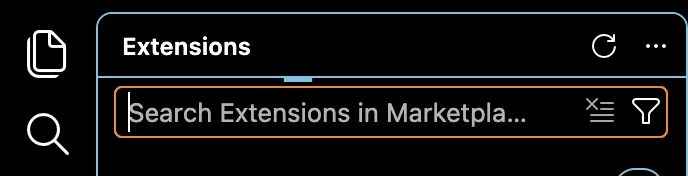

then search for and install each of these three:

| Extension | Publisher | Purpose |
|---|---|---|
| Python | Microsoft | Interpreter and environment management |
| Jupyter | Microsoft | Renders and runs `.ipynb` notebooks inside VS Code |
| Claude Code | Anthropic | The Claude panel |

You also need **ffmpeg** to render movies. Check with `ffmpeg -version` in a terminal; install with `brew install ffmpeg` (macOS) or `sudo apt install ffmpeg` (Linux).

Finally, confirm you have **Python 3.11 or newer** with `python3 --version`. Older releases — notably the Python 3.9 bundled with older macOS — are past end-of-life and pin you to outdated NumPy versions. Install a current release from [python.org](https://www.python.org/downloads/) if needed.

### 0.2 Open the project folder

In VS Code choose **File → Open Folder…** and select the folder containing this notebook.

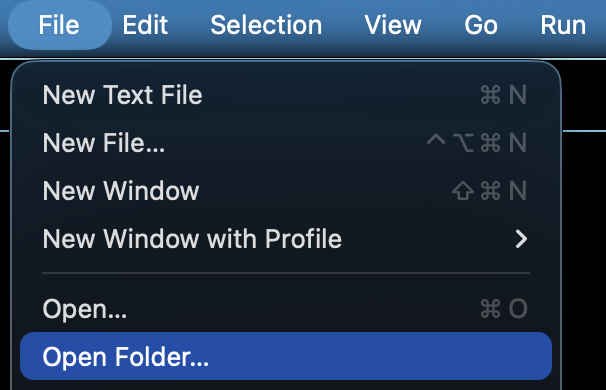

Open the *folder*, not just the notebook file: this is what lets Claude see your simulation scripts and the `simulations/` and `movies/` directories it will create.

### 0.3 Create the Python environment

Open the Command Palette (`Cmd+Shift+P` / `Ctrl+Shift+P`) and run:

```
Python: Create Environment
```

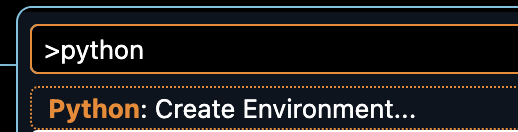

When prompted, choose **Venv**, then your Python 3.11+ interpreter. VS Code creates a `.venv` folder inside the project and selects it as the active interpreter.

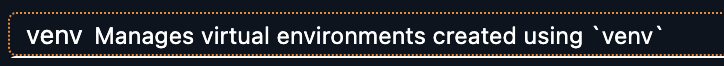

The example image below is specific, and will differ based on your machine / local Python installation and environment.

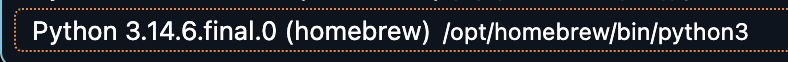

Select "Skip package installation"; we will install the specific packages we need in a moment.

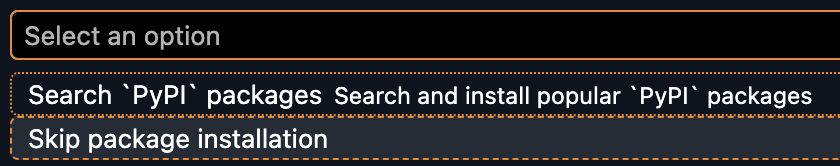

Then open a terminal inside VS Code (**Terminal → New Terminal**.

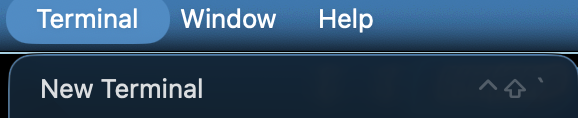

It activates `.venv` automatically, shown by `(.venv)` in the prompt) and install the packages:

```bash
pip install ipykernel numpy matplotlib
```

`ipykernel` is what lets VS Code execute this notebook. The Jupyter extension talks to the kernel directly, so there is no Jupyter server, URL, or access token anywhere in this setup.

### 0.4 Open the notebook and select the kernel

Open `gas_cloud_collapse.ipynb` from the VS Code Explorer. 

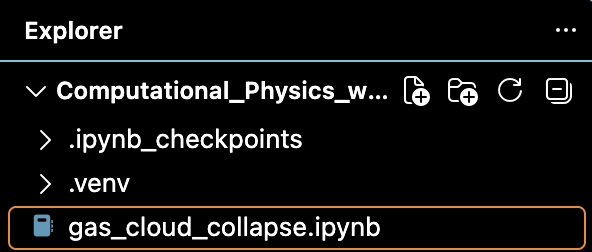

At the top right of the notebook click **Select Kernel**

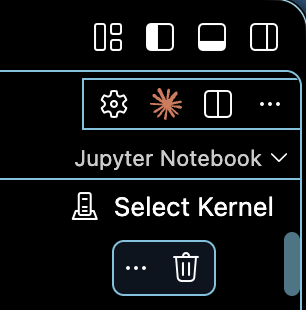

then **Python Environments…**, then the `.venv` entry (which may or may not be marked *Recommended*).

Run the verification cell below titled "# ── Environment check ───" with `Shift+Enter`. It should print your Python version and the NumPy and Matplotlib versions.

### 0.5 Dock Claude beside the notebook

Open the Command Palette again and run:

```
Claude Code: Open in Side Bar
```

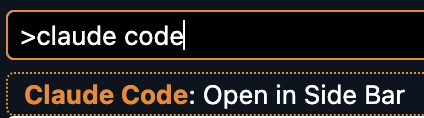

Claude opens in a panel next to the editor, giving you the notebook and Claude side-by-side. Sign in when prompted on first use.

| Shortcut | Action |
|---|---|
| `Cmd+Esc` / `Ctrl+Esc` | Move focus between the notebook and the Claude input |
| `Cmd+Shift+Esc` | Open Claude as a full editor tab instead of a panel |
| `Alt+K` | Insert an @-mention referencing the current file |

### 0.6 Verification and work division

One thing to note is that the level of effort and choice of LLM model will impact the final results. During testing, we used Claude's Opus 5 model with 1M context at max effort. We therefore suggest using these settings throughout the course of this notebook.

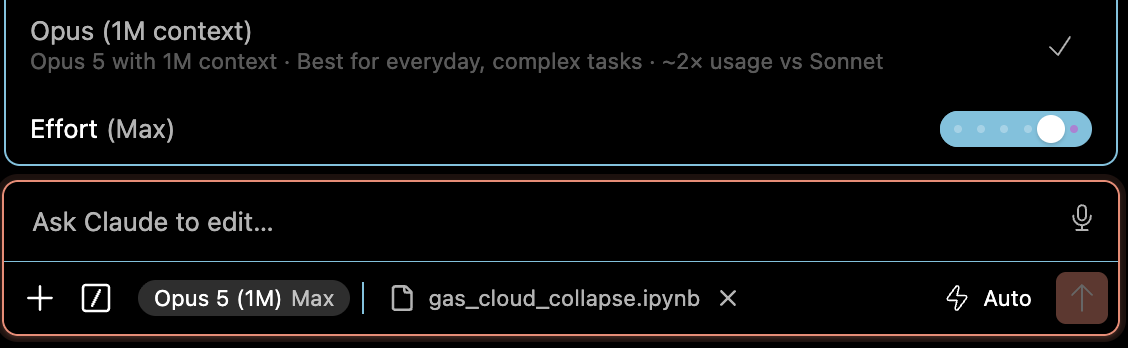

Ask Claude in the panel:

> Which file is open in my editor, and what are its section headings?

If Claude names this notebook, your setup is complete.

Throughout the module the work splits three ways:

- **Claude writes code** into notebook cells and into `.py` files. Its edits arrive as diffs you accept or reject.
- **You run notebook cells** with `Shift+Enter` and watch the output appear inline.
- **Claude runs simulations** as scripts in the VS Code terminal, since those run for minutes at a time.

**Troubleshooting**

- *`.venv` is not offered under Select Kernel:* the environment was created after the notebook was opened. Run `Developer: Reload Window` from the Command Palette, then select the kernel again.
- *Kernel fails to start, or VS Code reports that ipykernel is required:* run `pip install ipykernel` in the VS Code terminal with `(.venv)` showing in the prompt.
- *No Claude panel appears:* confirm the Claude Code extension is installed and enabled in the Extensions view, then reload the window.
- *A Claude edit to the notebook does not show up:* save the notebook (`Cmd+S`) before asking Claude to modify it — unsaved editor changes conflict with edits written to disk.

In [ ]:
# ── Environment check ────────────────────────────────────────────────────────
# Run with Shift+Enter after selecting the .venv kernel (Section 0.4).
import sys

print("Python:", sys.version.split()[0])
for pkg in ("numpy", "matplotlib"):
    try:
        print(f"{pkg}:", __import__(pkg).__version__)
    except ImportError:
        print(f"{pkg}: MISSING - ask Claude to install it")

## 1. Introduction: Computational Physics with LLMs

This module introduces undergraduate physics students to computational physics through LLM-assisted code development. The scenario is the self-gravitational collapse of a molecular gas cloud to form a young stellar cluster. All students build the same base N-body simulation, then branch into one of three physics tracks.

The main takeaway is learning to design, validate, and experiment with a computational physics code. The specific scenario — gravitational collapse — is the specific choice of problem we have chosen for developing this skill across multiple areas of physics.

| Route | Topic | Approx. time per feature |
|---|---|---|
| **A — Classical Mechanics** | Density structure, angular momentum, virial ratio | 5–10 min |
| **B — Statistical Mechanics / Thermo** | Equation of state, sink particles + accretion | ~20 min |
| **C — Computational Physics** | Barnes–Hut tree force, large N | ~20 min |

## 2. Physics Overview: Gas Cloud Collapse

This section provides the physical and mathematical background for the simulation, with emphasis on the topics explored in each route.

### 2.1 N-body Gravity and Numerical Integration

The equation of motion for particle $i$ under Newtonian gravity with Plummer \
gravitational softening $\varepsilon$:

$$\ddot{\mathbf{r}}_i = \sum_{j \neq i} \frac{G m_j\,(\mathbf{r}_j - \mathbf{r}_i)}{\bigl(|\mathbf{r}_j - \mathbf{r}_i|^2 + \varepsilon^2\bigr)^{3/2}}$$

The softening length $\varepsilon$ prevents force divergence at close separations and \
models the finite size of the gas parcels each particle represents. It should satisfy \
$\varepsilon \lesssim R_0/N^{1/3}$ (the mean inter-particle spacing).

Time integration uses the **symplectic leapfrog (KDK)** scheme, which conserves a \
modified energy without secular drift:

$$\mathbf{v}_i^{n+1/2} = \mathbf{v}_i^n + \tfrac{\Delta t}{2}\,\mathbf{a}_i^n \qquad \text{(half kick)}$$

$$\mathbf{r}_i^{n+1} = \mathbf{r}_i^n + \Delta t\,\mathbf{v}_i^{n+1/2} \qquad \text{(drift)}$$

$$\mathbf{v}_i^{n+1} = \mathbf{v}_i^{n+1/2} + \tfrac{\Delta t}{2}\,\mathbf{a}_i^{n+1} \qquad \text{(half kick)}$$

Simulation units: $G = M_\text{total} = R_0 = 1$, so energies are in units of \
$GM^2/R_0$ and times in units of $\sqrt{R_0^3/GM}$.

### 2.2 Jeans Instability and Free-fall Collapse

A gas cloud collapses when gravity overcomes thermal pressure support. The critical \
mass below which pressure prevents collapse is the **Jeans mass**:

$$M_J = \left(\frac{5k_B T}{G m_p}\right)^{3/2} \sqrt{\frac{3}{4\pi\rho}}$$

Our simulation starts from a cold ($T \approx 0$) cloud with $M \gg M_J$, so it \
collapses freely. The timescale for pressureless collapse of a uniform sphere is the \
**free-fall time**:

$$t_\text{ff} = \sqrt{\frac{3\pi}{32G\rho_0}} = \frac{\pi}{2\sqrt{2}}\sqrt{\frac{R_0^3}{GM}}$$

In simulation units ($G = M = R_0 = 1$): $t_\text{ff} = \pi/(2\sqrt{2}) \approx 1.11$. \
The simulation runs to $\sim 3\text{–}4\,t_\text{ff}$ to capture the full collapse \
and post-collapse virialization.

### 2.3 The Virial Theorem *(Route A — Classical Mechanics)*

For a self-gravitating system in statistical equilibrium, the **virial theorem** relates \
the time-averaged kinetic and gravitational potential energies:

$$2\langle T \rangle + \langle W \rangle = 0$$

The **virial ratio** $\alpha$ measures the degree of kinetic support against gravity:

$$\alpha \equiv \frac{\langle T \rangle}{|\langle W \rangle|}$$

| $\alpha$ | Physical interpretation |
|---|---|
| $0$ | Cold cloud — no kinetic support, pure free-fall collapse |
| $< 0.5$ | Sub-virial — collapses, but more slowly than free-fall |
| $= 0.5$ | Virial equilibrium — cloud neither collapses nor disperses |
| $> 0.5$ | Super-virial — cloud disperses |

Real molecular clouds are sub-virial ($\alpha \lesssim 0.5$).

**Two conventions are in common use, and they differ by a factor of two.** The ratio above, $\alpha = \langle T \rangle / |\langle W \rangle|$, equals $0.5$ at equilibrium. Much of the literature instead uses

$$Q \equiv \frac{2\langle T \rangle}{|\langle W \rangle|}$$

which equals $1$ at equilibrium. Whenever you plot a virial ratio, state which convention you are using and mark its equilibrium value on the axis — otherwise the reference line ends up in the wrong place and a perfectly virialized system looks like a failed check.

**Angular momentum** creates a centrifugal barrier that halts collapse perpendicular \
to the rotation axis, leading to disk formation. A cloud with specific angular momentum \
$\ell = |\mathbf{L}|/M$ produces a disk of characteristic radius:

$$r_\text{disk} \sim \frac{\ell^2}{GM}$$

**Density clumping**: real molecular clouds are not uniform — their density probability \
distribution is approximately log-normal. Denser clumps have shorter free-fall times \
($t_\text{ff} \propto \rho^{-1/2}$) and collapse first, producing hierarchical fragmentation.

### 2.4 Thermal Gas Physics *(Route B — Statistical Mechanics / Thermodynamics)*

Even a cold initial cloud heats up during collapse via adiabatic compression. A \
**polytropic equation of state (EOS)** relates pressure and density:

$$P = K\rho^\gamma$$

where $\gamma = 5/3$ for a monatomic ideal gas (adiabatic index) and $K$ is the \
polytropic constant fixed by the initial Mach number. The effective temperature is \
$\tilde{T}_i = P_i/\rho_i = K\rho_i^{\gamma-1}$, which rises as the cloud compresses.

Incorporating pressure forces requires knowing the local density at each particle, \
estimated using **smooth particle hydrodynamics (SPH)**:

$$\rho_i = \sum_j m_j\,W(|\mathbf{r}_i - \mathbf{r}_j|,\, h)$$

with a Gaussian kernel of smoothing length $h$:

$$W(r,\,h) = \frac{1}{(\sqrt{\pi}\,h)^3}\,\exp\!\left(-\frac{r^2}{h^2}\right)$$

The SPH pressure acceleration on particle $i$ in the symmetric (momentum-conserving) form:

$$\mathbf{a}_i^P = \frac{2}{h^2}\sum_j m_j\!\left(\frac{P_i}{\rho_i^2} + \frac{P_j}{\rho_j^2}\right)(\mathbf{r}_j - \mathbf{r}_i)\,W_{ij}$$

**Sink particles** represent protostellar objects forming where: (1) the local density \
exceeds a threshold, and (2) the velocity field is converging ($\nabla\cdot\mathbf{v} < 0$). \
Gas particles gravitationally bound to a sink are accreted, and each accretion event \
deposits **accretion luminosity** as an outward heating kick to surrounding gas:

$$\Delta E_\text{heat} = \eta\,\frac{G M_*\,\delta m}{r_\text{acc}}$$

where $\eta \sim 0.1$ is the radiative efficiency and $r_\text{acc}$ is the accretion radius.

### 2.5 Computational Scaling *(Route C — Computational Physics)*

Direct force evaluation requires all $N(N-1)/2$ pairwise interactions, scaling as $\mathcal{O}(N^2)$. A NumPy-vectorised version is fast for small $N$, but the $(N,N,3)$ temporary it allocates is 2.2 GB at $N = 10^4$ and 224 GB at $N = 10^5$ — it becomes *impossible* well before it becomes slow.

The **Barnes–Hut tree code** replaces distant particle groups with their monopole (centre-of-mass) approximation. The volume is partitioned into an octree; a source cell of side $s$ at distance $d$ from a target is treated as a point mass when:

$$\frac{s}{d} < \theta \quad \text{(far field — monopole)} \qquad \frac{s}{d} \geq \theta \quad \text{(open cell — recurse)}$$

where $\theta \approx 0.5$ is the **opening angle**. Each target visits $\mathcal{O}(\log N)$ nodes, giving $\mathcal{O}(N\log N)$ overall.

**Vectorise the traversal, not just the arithmetic inside each leaf.** This is the part that decides whether you actually observe $N\log N$. Big-O counts *operations* and assumes each costs the same — in Python that assumption fails. A tree walked one node at a time in a Python loop costs roughly 5 µs per node visit regardless of $N$, while NumPy evaluates a direct pair in about 15 ns. Walked that way the tree does about 6× fewer operations but pays about 80× more for each, so it measures $p \approx 1.4$ and runs more than 10× *slower* than direct summation.

Instead, hold the entire frontier of (target leaf, source node) pairs in NumPy arrays and advance it one tree **level** at a time: evaluate the opening criterion for every pair at once, split into accept / open / leaf with boolean masks, and expand the opened pairs to their children with `np.repeat` and a ragged-range gather. Python-level iterations then number the tree *depth* (about 5) instead of the node visits (about $10^6$).

**Keep the leaf size small** (8 or fewer). Large leaves make the tree shallow, so the opening criterion rarely accepts, the near field dominates and grows faster than linearly, and the scaling degrades. (Large leaves help only a Python node-walk, where they buy fewer iterations — that trade-off disappears once the traversal is vectorised.)

| Method | Complexity | Measured on a reference implementation |
|---|---|---|
| Direct, NumPy einsum | $\mathcal{O}(N^2)$ | $p = 2.00$; memory-bound above $N \sim 10^4$ |
| Barnes–Hut, Python node walk | $\mathcal{O}(N\log N)$ in theory | $p \approx 1.4$; slower than direct at every reachable $N$ |
| Barnes–Hut, NumPy level-synchronous | $\mathcal{O}(N\log N)$ | $p \approx 1.09$ (ideal 1.11); overtakes direct near $N \sim 2000$ |

### 2.6 Validating Your Code

A simulation that runs is not necessarily a simulation that is correct. For every feature you implement, this module generates a **validation panel**: an extra panel in the movie, animating frame by frame alongside the 3D view, plotting a measured quantity against the analytic prediction for it. The first movie (section 3.4) shows a single run, so the panel sits beside one 3D view; from section 3.6 onward the movie compares two runs side by side and the validation panel becomes the third.

The panel carries two quantities. The **primary** one stays the same throughout — the half-mass radius — because a uniform sphere collapsing under gravity alone follows a closed-form (exact) solution, so the cold baseline gives you a curve checkable against theory with no free parameters. Each feature then adds a **secondary** quantity on a twin right-hand axis, chosen because it has a known expected value:

| Feature | Secondary quantity |
|---|---|
| Base code | mass-radius concentration ratio |
| A1 clumpy | width of the local density distribution |
| A2 rotating | total angular momentum |
| A3 virial | virial ratio |
| B1 equation of state | total energy, including internal energy |
| B2 sink particles | sink mass fraction, and total mass |
| C1 Barnes–Hut | fitted scaling exponent (smoke tests, no movie) |

**Deriving the reference is the exercise.** This notebook deliberately ships no validation library and quotes no expected numbers. Ask your LLM to derive the analytic prediction from first principles, state the assumptions it rests on, and say where those assumptions stop holding. Then read the result the right way round: the cold baseline should sit on the analytic curve until softening takes over, and each feature run should *depart* from it in a way you can explain physically. The departure is the physics that you have introduced with your new code feature.

If a check fails, suspect the simulation before the theory — but check the derivation too, and make your LLM show it to you.

**Plotting a conserved quantity.** Some of the secondary quantities are conserved *exactly* rather than approximately — total angular momentum, and total mass under accretion. Such a quantity varies only at the level of floating-point roundoff, so an autoscaled axis will magnify that noise into what looks like violent structure and make your strongest check read as your worst plot. Fix the axis to a range in which the reference line is visibly flat, and state the maximum deviation numerically instead. If a conservation check genuinely fails, replot the deviation from the reference on a logarithmic axis, where roundoff and a real bug are easy to tell apart.

**When the secondary quantity misses its reference.** It often will, and that is usually physical rather than a bug: mass escapes the system and carries kinetic energy with it, softening biases the potential, and a collapsed remnant may still be relaxing. Restricting a global ratio to the gravitationally bound particles is often the right refinement, though it will not always close the gap either. Treat a persistent offset as something to explain, and never adjust the analytic reference to make it agree. Remember too that an analytic reference is a continuum result: a finite particle number scatters the measured value around it by roughly $N^{-1/2}$, which at $N = 10^3$ is a few percent. Estimate that scatter before reading anything into a small offset, and make sure any separation you claim between two runs is larger than it.

## Choosing Your Route

Everyone builds the same base N-body code (Section 3). After that, the module branches into one of three routes — pick the one whose physics interests you most. You only commit to one for this module; features from other routes can always be stacked on later (Section 4).

### Route A — Classical Mechanics

*What you change:* the initial conditions and global dynamics of the cloud, leaving the force calculation untouched.

*Features:* clumpy (non-uniform) initial density; cloud rotation leading to protostellar disk formation; an artificial virial ratio controlling kinetic support against collapse.

*Best if you want:* the most direct connection between a mechanics concept (angular momentum, the virial theorem) and a visible change in the collapse. The features are quick (~5–10 minutes each) and cheap in LLM tokens, so you can try all three.

*Physics background:* Section 2.3.

### Route B — Statistical Mechanics and Thermodynamics

*What you change:* the gas itself becomes a thermodynamic fluid — you add an equation of state with SPH pressure feedback, then sink particles that accrete gas and heat their surroundings with accretion luminosity.

*Best if you want:* to see microscopic thermodynamics (pressure, temperature, heating) shape macroscopic structure. This is the most substantial code development (~20 minutes and the highest token cost per feature) and effectively turns the code into a minimal hydrodynamics + star formation simulation.

*Physics background:* Section 2.4.

### Route C — Computational Physics Optimization

*What you change:* not the physics — the algorithm. You replace the direct $\mathcal{O}(N^2)$ force sum with a Barnes–Hut octree at $\mathcal{O}(N\log N)$ and raise the particle count by an order of magnitude.

*Best if you want:* to learn how research codes actually reach large $N$: tree data structures, complexity analysis, vectorisation, and profiling. The collapse looks the same — the point is measuring that it runs vastly faster per particle (~20 minutes).

*Physics background:* Section 2.5.

---

Work through the section below that matches your choice. Tell Claude which route you have picked when you start, so it can tailor its suggestions to the physics you care about.

## 3. Building the Base N-body Code

> *Dependency assumptions: VS Code with the Python, Jupyter, and Claude Code extensions; ffmpeg*

Work through the prompts below in order, typing each one into the Claude panel. Claude writes code into the cells and into `.py` script files, and launches long-running simulations in the VS Code terminal; you run the notebook cells yourself with `Shift+Enter`. Read each physics section before issuing the next prompt, and ask Claude follow-up questions as they come up.

### 3.1 The N-body Simulation

> **Prompt:**
>
> Write a simple N-body code in Python to simulate the self-gravitational collapse of a cold gas cloud. Ensure that the code outputs snapshots of the gas cloud's evolution every 10 timesteps (using dt = 0.001 and 4000 steps) to a `simulations` directory which can be used by an external plotting script to generate a movie.

Claude will ask clarifying questions about integration method, initial conditions, softening, and simulation parameters, and will provide suggested values. Accept the defaults or explore alternatives — we will discuss the choices while the simulation runs.

In [1]:
# Claude writes the N-body simulation code here - run it with Shift+Enter.

### 3.2 Visualization

> **Prompt:**
>
> Generate a plotting script which uses the snapshots of the gas cloud's evolution to generate a 3D movie with stationary axes in a separate `movies` directory.

In [ ]:
# Claude writes the movie-generation plotting script here - run it with Shift+Enter.

### 3.3 Running the Simulation

> **Prompt:**
>
> Run a simulation, ensuring that it is saved as a separate subdirectory in the simulations directory. When the simulation is finished, generate a movie of the simulation and display it in the cell below by referencing the saved file rather than embedding it. If no video appears, the notebook renderer is sandboxing the output and blocking the relative path — VS Code does this — so either embed the file instead (these movies are only a few hundred kB) or open it directly from the `movies` directory. While the simulation and movie generation are running, explain the mathematical and physics choices made during code design and how they and their alternatives can affect the code's results.

Also add the validation panel described in Section 2.6 to this first movie, deriving the analytic reference yourself rather than looking it up.

<!-- VALIDATION SPEC — for the assistant; not rendered in the notebook.
Regenerate this validation from first principles for this run. Do not rely on
a previously written validation module, on cached results, or on expected
values quoted elsewhere; derive the analytic reference yourself and state the
assumptions it rests on.
Panel: second panel of this single-run movie, beside the one 3D view,
animating frame by frame with it — curves revealed up to the current
frame, marker at the current time, analytic reference drawn in full as a
dashed target. The two-run side-by-side layout is only introduced in
section 3.6; from there on this validation panel becomes the third panel.
Primary quantity (left axis):    half-mass radius
Secondary quantity (right axis): mass-radius concentration ratio
-->

In [ ]:
# Claude launches the simulation and movie render in the VS Code terminal
# (several minutes). Use this cell to load a snapshot and inspect the results.

### 3.4 Identifying Limitations

> **Prompt:**
>
> List some of the limitations of our code, specifically focusing on missing physics or inefficient computational choices as compared to research-grade N-body code design. Prioritize topics related to classical mechanics, statistical mechanics and thermodynamics, and computational physics algorithm optimizations.

In [ ]:
# Claude reports the limitations in the side panel - use this cell for any diagnostic it suggests.

### 3.5 Preparing for the Feature Extension

Before implementing your chosen route's feature(s), start with the following **context prompt**. After this, you can continue with your route-specific prompts as you add additional features to your code.

> **Prompt (prefix — attach your route's prompt at the end):**
>
> Modify the plotting script to generate a movie of two runs side-by-side for all future prompts. When asked to run a new simulation, ensure that it has the same simulation hyperparameters (duration, timesteps, etc.) as the initial simulation. Add all following modifications to the code in a modular way such that the user can use a flag to determine whether or not the modification is applied during simulation.

---

**Continue in the route section below that matches your choice.**

---

## Route A: Classical Mechanics

*The classical mechanics route. Skip ahead to Route B or C if you chose one of those instead.*

Each feature below can be implemented independently. Pick one, or chain them if time allows.

### A1. Clumpy Initial Density Distribution (~5 minutes)

Real molecular clouds have pockets of higher and lower density rather than a uniform distribution. A clumpy initial condition — particles drawn from a log-normal density field or arranged in overlapping Gaussian sub-clumps — produces more realistic fragmentation during collapse. Denser clumps collapse faster ($t_\text{ff} \propto \rho^{-1/2}$), leading to multiple collapse centres.

**How to read the panel.** That $t_\text{ff} \propto \rho^{-1/2}$ speedup governs individual clumps collapsing *locally*. The half-mass radius on the primary axis is a *global* measure, fixed by the cloud's mean density — and redistributing the same mass into clumps does not change the mean. So expect the global collapse to track the uniform run closely, or even to lag it slightly, since the velocity dispersion that local collapse stirs up adds a little support. Fragmentation shows up on the secondary axis, not the primary one. If you want to test the $\rho^{-1/2}$ scaling itself, you need a per-clump collapse time against that clump's own density, which is a different measurement from anything the panel plots.

> **Prompt:**
>
> Rather than assuming a uniformly distributed initial gas cloud, implement a more realistic density distribution to mimic a gas cloud that has pockets of lower and higher density, representing clumps of gas.

Then add the validation panel described in Section 2.6 to the movie, deriving the analytic reference yourself rather than looking it up.

<!-- VALIDATION SPEC — for the assistant; not rendered in the notebook.
Regenerate this validation from first principles for this run. Do not rely on
a previously written validation module, on cached results, or on expected
values quoted elsewhere; derive the analytic reference yourself and state the
assumptions it rests on.
Panel: third panel of the side-by-side movie, animating frame by frame with
the two 3D views — curves revealed up to the current frame, marker at the
current time, analytic reference drawn in full as a dashed target.
Primary quantity (left axis):    half-mass radius
Secondary quantity (right axis): width of the local density distribution
                                 (estimate a per-particle density first)
-->

In [ ]:
# Claude implements clumpy initial conditions, then runs the comparison in the terminal.
# Use this cell to inspect the two runs.

### A2. Angular Momentum and Disk Formation (~5 minutes)

As a result of the angular momentum inherited from the host galaxy, a realistic gas \
cloud has a non-zero angular momentum component. Rather than collapsing to a central \
point, a rotating cloud forms a disk. The disk radius scales as:

$$r_\text{disk} \sim \frac{\ell^2}{GM}$$

where $\ell = |\mathbf{L}|/M$ is the specific angular momentum. The collapse proceeds \
along the rotation axis but is halted perpendicular to it by the centrifugal barrier.

> **Prompt:**
>
> Implement a non-zero angular momentum component to the initial gas cloud to simulate \
protostellar disk formation.

Then add the validation panel described in Section 2.6 to the movie, deriving the analytic reference yourself rather than looking it up.

<!-- VALIDATION SPEC — for the assistant; not rendered in the notebook.
Regenerate this validation from first principles for this run. Do not rely on
a previously written validation module, on cached results, or on expected
values quoted elsewhere; derive the analytic reference yourself and state the
assumptions it rests on.
Panel: third panel of the side-by-side movie, animating frame by frame with
the two 3D views — curves revealed up to the current frame, marker at the
current time, analytic reference drawn in full as a dashed target.
Primary quantity (left axis):    half-mass radius
Secondary quantity (right axis): total angular momentum
-->

In [ ]:
# Claude adds solid-body rotation, then runs the comparison in the terminal.
# Use this cell to inspect the two runs.

### A3. Artificial Virial Ratio (~10 minutes)

Systems governed by inverse-square-law forces obey the virial theorem. Our cold initial \
cloud has $\alpha = 0$ (pure free-fall), but real molecular clouds have \
$0 < \alpha \lesssim 0.5$. Rather than computing $\alpha$ self-consistently from \
thermodynamics, we can artificially rescale the initial velocities to fix $\alpha$ \
and observe how the collapse timescale and final morphology change.

> **Prompt:**
>
> Implement an artificial virial ratio parameter which fixes the ratio of the kinetic \
energy to the gravitational potential energy over the duration of the simulation.

Then add the validation panel described in Section 2.6 to the movie, deriving the analytic reference yourself rather than looking it up.

<!-- VALIDATION SPEC — for the assistant; not rendered in the notebook.
Regenerate this validation from first principles for this run. Do not rely on
a previously written validation module, on cached results, or on expected
values quoted elsewhere; derive the analytic reference yourself and state the
assumptions it rests on.
Panel: third panel of the side-by-side movie, animating frame by frame with
the two 3D views — curves revealed up to the current frame, marker at the
current time, analytic reference drawn in full as a dashed target.
Primary quantity (left axis):    half-mass radius
Secondary quantity (right axis): virial ratio (state which convention you
                                 use and mark its equilibrium value)
-->

In [ ]:
# Claude implements virial-ratio control, then runs the comparison in the terminal.
# Use this cell to inspect the two runs.

---

## Route B: Statistical Mechanics and Thermodynamics

*The statistical mechanics and thermodynamics route. Skip to Route A or C if you chose one of those instead.*

> **Note:** The changes required to incorporate temperature evolution involve substantial additions to the base code and will incur a higher LLM token cost. These features require more thinking time and implementing multiple features may require longer than the allotted class period. Each feature takes approximately 20 minutes.

### B1. Equation of State and SPH Pressure (~20 minutes)

Even a cold initial cloud heats up as it collapses: adiabatic compression raises the thermal pressure, which resists further collapse. Incorporating this converts the code into a minimal smooth particle hydrodynamics (SPH) simulation: the local density is estimated at each particle, a polytropic EOS yields the pressure, and the resulting pressure gradient force is added to the gravitational acceleration.

> **Prompt:**
>
> Implement a simple equation of state in the gas that connects the gas cloud's density to temperature and incorporate the gas temperature feedback into the collapse dynamics.

Then add the validation panel described in Section 2.6 to the movie, deriving the analytic reference yourself rather than looking it up.

<!-- VALIDATION SPEC — for the assistant; not rendered in the notebook.
Regenerate this validation from first principles for this run. Do not rely on
a previously written validation module, on cached results, or on expected
values quoted elsewhere; derive the analytic reference yourself and state the
assumptions it rests on.
Panel: third panel of the side-by-side movie, animating frame by frame with
the two 3D views — curves revealed up to the current frame, marker at the
current time, analytic reference drawn in full as a dashed target.
Primary quantity (left axis):    half-mass radius
Secondary quantity (right axis): total energy, including the internal
                                 energy of the gas (take the polytropic
                                 constant and index from your own equation
                                 of state, not from anywhere else)
-->

In [ ]:
# Claude implements the SPH density estimator, polytropic EOS, and pressure force,
# then runs the comparison in the terminal. Use this cell to inspect the two runs.

### B2. Sink Particles and Accretion Luminosity (~20 minutes)

As the cloud collapses, dense pockets exceed the local Jeans density and begin forming protostellar objects. These are represented as **sink particles** that grow by accreting surrounding gravitationally bound gas. The energy released by accretion is partly radiated away and partly deposited as heat in the surrounding gas — a feedback mechanism that slows further star formation.

> **Prompt:**
>
> Implement sink particles which represent protostellar objects forming in regions of dense bound gas and implement a heating term from these sink particles which represents accretion luminosity emitted by these protostellar objects.

Then add the validation panel described in Section 2.6 to the movie, deriving the analytic reference yourself rather than looking it up.

<!-- VALIDATION SPEC — for the assistant; not rendered in the notebook.
Regenerate this validation from first principles for this run. Do not rely on
a previously written validation module, on cached results, or on expected
values quoted elsewhere; derive the analytic reference yourself and state the
assumptions it rests on.
Panel: third panel of the side-by-side movie, animating frame by frame with
the two 3D views — curves revealed up to the current frame, marker at the
current time, analytic reference drawn in full as a dashed target.
Primary quantity (left axis):    half-mass radius
Secondary quantity (right axis): sink mass fraction
Also report:                     total mass (gas + sinks) at every snapshot
-->

In [ ]:
# Claude implements sink creation, accretion, and luminosity feedback,
# then runs the comparison in the terminal. Use this cell to inspect the two runs.

---

## Route C: Computational Physics Optimization

*The computational physics route. Skip to Route A or B if you chose one of those instead.*

### C1. Barnes–Hut Tree Force and Large N (~20 minutes)

Currently, each force evaluation compares all $N(N-1)/2$ particle pairs, scaling as $\mathcal{O}(N^2)$. The **Barnes–Hut algorithm** groups distant particles into an octree and approximates their combined gravitational effect as a point mass when the opening criterion $s/d < \theta$ is satisfied, reducing the complexity to $\mathcal{O}(N\log N)$.

Whether you *measure* that scaling depends entirely on how the tree is walked — see Section 2.5. Walking it node by node in a Python loop costs a fixed ~5 µs per visit and loses to vectorised direct summation by more than 10×. The traversal itself has to be done in NumPy, which is what the prompt below asks for.

> **Prompt:**
>
> Implement the Barnes-Hut tree algorithm using NumPy for the tree traversal itself, \
> not only for the per-leaf arithmetic. Flatten the octree into arrays and advance the \
> whole frontier of (target leaf, source node) pairs one tree level at a time, so that \
> the number of Python-level iterations is the depth of the tree rather than the number \
> of node visits. Do not walk the tree node by node in a Python loop, and use a small \
> leaf size. Rather than generating a full simulation, run some smoke tests for various \
> values of N, up to 10 times as many particles as in the initial simulation. Generate a \
> scaling plot of runtime as a function of N to showcase the benefit of the Barnes-Hut \
> algorithm. Plot the actual runtimes for this code against the theoretical scalings \
> ($N^2$ vs. $N \log N$), and report the fitted exponent for each method.

If your fitted exponent for the tree comes out near 1.4 rather than near 1.1, the traversal is still running in Python somewhere — that is the single most common outcome, and finding it is the point of the exercise.

Also report the validation quantities listed in Section 2.6 for this route, deriving the expected scalings yourself rather than looking them up.

<!-- VALIDATION SPEC — for the assistant; not rendered in the notebook.
Regenerate this validation from first principles for this run. Do not rely on
a previously written validation module, on cached results, or on expected
values quoted elsewhere; derive the analytic reference yourself and state the
assumptions it rests on.
No movie for this feature — smoke tests only.
Primary quantity:    wall-clock time per force evaluation, vs N
Secondary quantity:  fitted scaling exponent for each method
Also report:         force error against direct summation
-->

In [2]:
# Claude implements the Barnes-Hut octree (cell-cell traversal, NumPy),
# then runs the large-N simulation in the terminal. Use this cell to inspect timings.

---

## 4. Comparison and Wrap-up

> **Prompt:**
>
> Run the simulation with the newly implemented feature and create a side-by-side \
movie comparing the two simulations.

Your movie may or may not make the differences immediately obvious. If the effect \
is subtle, ask Claude to highlight it — for example by adjusting the movie scale, \
reducing $\Delta t$ to slow the collapse, or adding a diagnostic plot \
(energy vs. time, sink count vs. time, wall-clock time per step, etc.).

From here the code is yours. You can:

- Add features modularly and compare them pairwise with a flag
- Stack multiple features and compare the full physics run to the base case
- Explore parameter sensitivity: virial ratio $\alpha$, EOS index $\gamma$, \
opening angle $\theta$, particle count $N$

> **Suggested follow-up prompts:**
>
> - *"Plot the kinetic energy, potential energy, and total energy as a function of time for both runs."*
> - *"Show the number of sink particles and their total accreted mass as a function of time."*
> - *"Increase N by another factor of 10 and compare the wall-clock time per step and the collapse morphology."*

In [ ]:
# Claude runs the final comparison and renders the side-by-side movie in the terminal.
# Use this cell to display the movie or compare frames.